# From Analysis to Production-Ready Data Pipelines

What separates a good analysis from a production-ready data solution?

A **data pipeline** is a structured, deterministic sequence of transformations that converts raw data into usable insights:
- **Structured sequence**: ordered steps from ingestion to transformation
- **Deterministic**: same input always produces the same output
- **Modular and testable**: components are independent and verifiable
- **Scalable**: can handle increasing data volumes efficiently

## The Evolution of a Data Scientist
1. **Writing Scripts** — quick, hard-coded analyses
2. **Building Notebooks** — interactive but often untidy
3. **Creating Workflows** — organised functions and reusable components
4. **Designing Pipelines** — production-ready systems with automation, testing and scalability

## Core Stages of a Data Pipeline

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 710 85" width="710" height="85">
  <!-- Ingest -->
  <rect x="5" y="10" width="140" height="60" rx="8" fill="#1565C0"/>
  <text x="75" y="36" text-anchor="middle" fill="white" font-family="Arial,sans-serif" font-size="13" font-weight="bold">Ingest</text>
  <text x="75" y="55" text-anchor="middle" fill="#BBDEFB" font-family="Arial,sans-serif" font-size="10">Files · APIs · Streams</text>
  <!-- Arrow 1 -->
  <line x1="145" y1="40" x2="158" y2="40" stroke="#607D8B" stroke-width="2"/>
  <polygon points="158,34 170,40 158,46" fill="#607D8B"/>
  <!-- Clean -->
  <rect x="170" y="10" width="140" height="60" rx="8" fill="#2E7D32"/>
  <text x="240" y="36" text-anchor="middle" fill="white" font-family="Arial,sans-serif" font-size="13" font-weight="bold">Clean</text>
  <text x="240" y="55" text-anchor="middle" fill="#C8E6C9" font-family="Arial,sans-serif" font-size="10">Nulls · Formats · Dupes</text>
  <!-- Arrow 2 -->
  <line x1="310" y1="40" x2="323" y2="40" stroke="#607D8B" stroke-width="2"/>
  <polygon points="323,34 335,40 323,46" fill="#607D8B"/>
  <!-- Transform -->
  <rect x="335" y="10" width="140" height="60" rx="8" fill="#E65100"/>
  <text x="405" y="36" text-anchor="middle" fill="white" font-family="Arial,sans-serif" font-size="13" font-weight="bold">Transform</text>
  <text x="405" y="55" text-anchor="middle" fill="#FFE0B2" font-family="Arial,sans-serif" font-size="10">Aggregate · Join · Reshape</text>
  <!-- Arrow 3 -->
  <line x1="475" y1="40" x2="488" y2="40" stroke="#607D8B" stroke-width="2"/>
  <polygon points="488,34 500,40 488,46" fill="#607D8B"/>
  <!-- Feature Engineering -->
  <rect x="500" y="10" width="200" height="60" rx="8" fill="#6A1B9A"/>
  <text x="600" y="36" text-anchor="middle" fill="white" font-family="Arial,sans-serif" font-size="13" font-weight="bold">Feature Engineering</text>
  <text x="600" y="55" text-anchor="middle" fill="#E1BEE7" font-family="Arial,sans-serif" font-size="10">Encode · Scale · Interact</text>
</svg>

In [1]:
import pandas as pd
import numpy as np

## 1. Characteristics of a Good Pipeline

| Property | Meaning |
|---|---|
| **Reproducible** | Same input → identical results; no hidden state |
| **Modular** | Each component does one clear task |
| **Transparent** | Readable logic; no magic numbers |
| **Configurable** | Parameters in config files, not hard-coded |
| **Easy to Debug** | Failures are isolated and traceable |

## 2. Functional Pipeline Design

Pure functions take input and return output **without modifying global state**. Each function is independent and composable.

In [2]:
# Sample dataset for demonstrating pipeline stages
raw_data = pd.DataFrame({
    'age':    [25, None, 35, 28, 45, None, 32],
    'income': [50000, 62000, None, 48000, 90000, 75000, 55000],
    'city':   ['Mumbai', 'Delhi', 'Mumbai', 'DELHI', 'Bangalore', 'mumbai', 'Delhi'],
    'score':  [7.2, 8.1, 6.5, None, 9.0, 7.8, 8.5]
})

print("Raw data:")
print(raw_data)
print(f"\nShape: {raw_data.shape}")
print(f"Nulls:\n{raw_data.isnull().sum()}")

Raw data:
    age   income       city  score
0  25.0  50000.0     Mumbai    7.2
1   NaN  62000.0      Delhi    8.1
2  35.0      NaN     Mumbai    6.5
3  28.0  48000.0      DELHI    NaN
4  45.0  90000.0  Bangalore    9.0
5   NaN  75000.0     mumbai    7.8
6  32.0  55000.0      Delhi    8.5

Shape: (7, 4)
Nulls:
age       2
income    1
city      0
score     1
dtype: int64


In [3]:
# Stage 1: Ingest — load data in a structured, traceable way
def ingest_data(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()
    print(f"[INGEST] Loaded {df.shape[0]} rows, {df.shape[1]} columns")
    return df


# Stage 2: Clean — handle missing values, inconsistent formats, duplicates
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['age'] = df['age'].fillna(df['age'].median())
    df['income'] = df['income'].fillna(df['income'].median())
    df['score'] = df['score'].fillna(df['score'].mean())
    df['city'] = df['city'].str.strip().str.title()
    print(f"[CLEAN] Remaining nulls: {df.isnull().sum().sum()}")
    return df


# Stage 3: Transform — reshape, aggregate, derive columns
def transform_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['income_thousands'] = df['income'] / 1000
    df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 100],
                             labels=['Young', 'Mid', 'Senior'])
    print(f"[TRANSFORM] Columns: {list(df.columns)}")
    return df


# Stage 4: Feature Engineering — create predictive variables
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['income_per_score'] = df['income'] / df['score']
    print(f"[ENGINEER] Final shape: {df.shape}")
    return df

In [4]:
# Run the functional pipeline sequentially
df = ingest_data(raw_data)
df = clean_data(df)
df = transform_data(df)
df = engineer_features(df)

print("\nFinal processed data:")
df

[INGEST] Loaded 7 rows, 4 columns
[CLEAN] Remaining nulls: 0
[TRANSFORM] Columns: ['age', 'income', 'city', 'score', 'income_thousands', 'age_group']
[ENGINEER] Final shape: (7, 7)

Final processed data:


,age,income,city,score,income_thousands,age_group,income_per_score
0,25.0,50000.0,Mumbai,7.20,50.0,Young,6944.444444
1,32.0,62000.0,Delhi,8.10,62.0,Mid,7654.320988
2,35.0,58500.0,Mumbai,6.50,58.5,Mid,9000.000000
3,28.0,48000.0,Delhi,7.85,48.0,Young,6114.649682
4,45.0,90000.0,Bangalore,9.00,90.0,Mid,10000.000000
5,32.0,75000.0,Mumbai,7.80,75.0,Mid,9615.384615
6,32.0,55000.0,Delhi,8.50,55.0,Mid,6470.588235


[INGEST] Loaded 7 rows, 4 columns
[CLEAN] Remaining nulls: 0
[TRANSFORM] Columns: ['age', 'income', 'city', 'score', 'income_thousands', 'age_group']
[ENGINEER] Final shape: (7, 7)


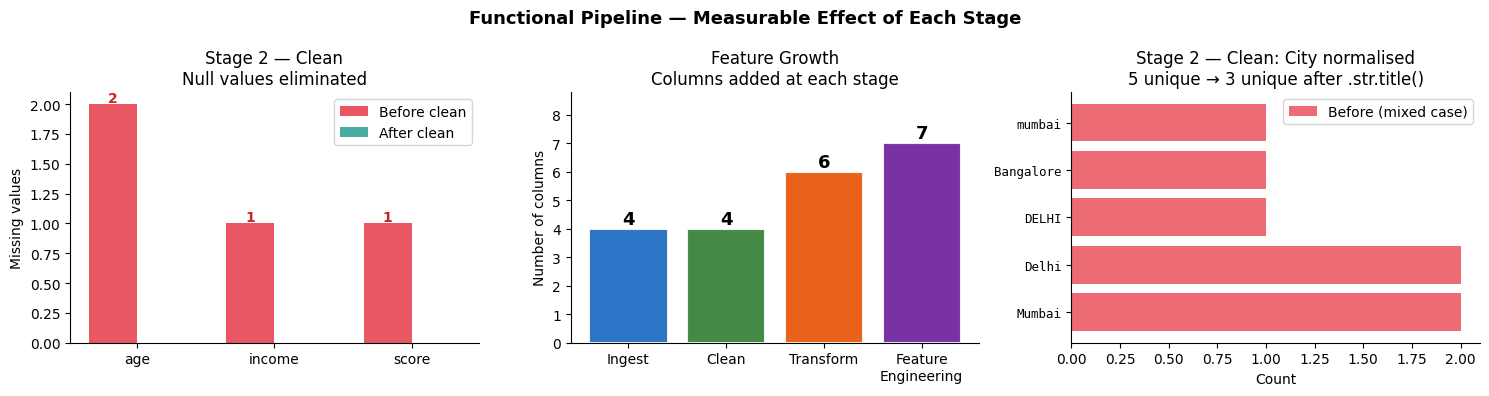

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Capture intermediate states for comparison
_raw   = ingest_data(raw_data)
_clean = clean_data(_raw)
_trans = transform_data(_clean)
_eng   = engineer_features(_trans)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Functional Pipeline — Measurable Effect of Each Stage',
             fontsize=13, fontweight='bold')

# ── Panel 1: Null counts before vs after Clean ───────────────────────────────
num_cols = ['age', 'income', 'score']
before_nulls = [_raw[c].isnull().sum()   for c in num_cols]
after_nulls  = [_clean[c].isnull().sum() for c in num_cols]

x = np.arange(len(num_cols))
w = 0.35
b1 = axes[0].bar(x - w/2, before_nulls, w, color='#e63946', alpha=0.85, label='Before clean')
b2 = axes[0].bar(x + w/2, after_nulls,  w, color='#2a9d8f', alpha=0.85, label='After clean')
axes[0].set_xticks(x)
axes[0].set_xticklabels(num_cols)
axes[0].set_ylabel('Missing values')
axes[0].set_title('Stage 2 — Clean\nNull values eliminated')
axes[0].legend()
for bar, val in zip(b1, before_nulls):
    if val:
        axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                     str(val), ha='center', fontsize=10, color='#c62828', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Panel 2: Column count growing through stages ─────────────────────────────
stage_labels = ['Ingest', 'Clean', 'Transform', 'Feature\nEngineering']
col_counts   = [_raw.shape[1], _clean.shape[1], _trans.shape[1], _eng.shape[1]]
stage_colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']

bars = axes[1].bar(stage_labels, col_counts, color=stage_colors,
                   edgecolor='white', linewidth=1.5, alpha=0.9)
for bar, count in zip(bars, col_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
                 f'{count}', ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(col_counts) + 1.8)
axes[1].set_ylabel('Number of columns')
axes[1].set_title('Feature Growth\nColumns added at each stage')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# ── Panel 3: City normalisation — unique values collapsed ────────────────────
city_before = _raw['city'].value_counts()
city_after  = _clean['city'].value_counts()

# Show all unique raw labels vs consolidated clean labels
all_labels = list(city_before.index)
before_vals = [city_before.get(l, 0) for l in all_labels]

y_pos = np.arange(len(all_labels))
axes[2].barh(y_pos, before_vals, color='#e63946', alpha=0.75, label='Before (mixed case)')
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(all_labels, fontsize=9, fontfamily='monospace')
axes[2].set_xlabel('Count')
axes[2].set_title(
    f'Stage 2 — Clean: City normalised\n'
    f'{_raw["city"].nunique()} unique → {_clean["city"].nunique()} unique after .str.title()'
)
axes[2].legend()
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Class-Based Pipeline Design

Class-based pipelines **maintain internal state** (e.g. mean, standard deviation, encoding mappings learned from training data). This mirrors scikit-learn's `fit()` / `transform()` pattern.

In [6]:
class DataCleaner:
    """Learns imputation values from training data and applies them to new data."""

    def __init__(self):
        self.fill_values_ = {}

    def fit(self, df: pd.DataFrame) -> 'DataCleaner':
        self.fill_values_['age'] = df['age'].median()
        self.fill_values_['income'] = df['income'].median()
        self.fill_values_['score'] = df['score'].mean()
        print(f"[FIT] Learned fill values: {self.fill_values_}")
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        for col, val in self.fill_values_.items():
            df[col] = df[col].fillna(val)
        df['city'] = df['city'].str.strip().str.title()
        print(f"[TRANSFORM] Applied learned fill values")
        return df


# Simulate train / test split
train_df = raw_data.iloc[:5].copy()
test_df  = raw_data.iloc[5:].copy()

cleaner = DataCleaner()
cleaner.fit(train_df)              # learn only from training data

train_clean = cleaner.transform(train_df)
test_clean  = cleaner.transform(test_df)   # same parameters applied

print("\nTrain cleaned:")
print(train_clean)
print("\nTest cleaned:")
print(test_clean)

[FIT] Learned fill values: {'age': np.float64(31.5), 'income': np.float64(56000.0), 'score': np.float64(7.7)}
[TRANSFORM] Applied learned fill values
[TRANSFORM] Applied learned fill values

Train cleaned:
    age   income       city  score
0  25.0  50000.0     Mumbai    7.2
1  31.5  62000.0      Delhi    8.1
2  35.0  56000.0     Mumbai    6.5
3  28.0  48000.0      Delhi    7.7
4  45.0  90000.0  Bangalore    9.0

Test cleaned:
    age   income    city  score
5  31.5  75000.0  Mumbai    7.8
6  32.0  55000.0   Delhi    8.5


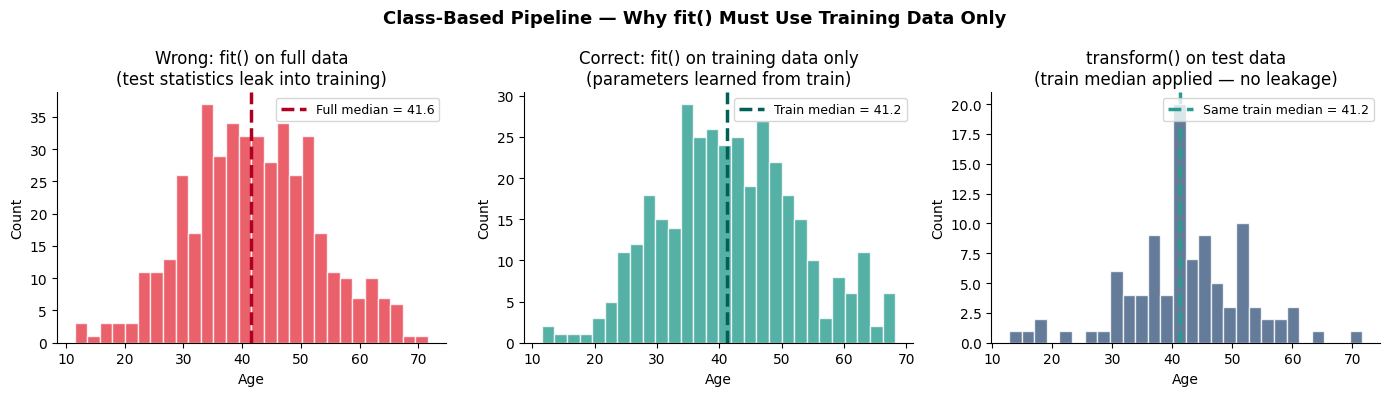

Full-data median : 41.57
Train-only median: 41.25
Difference       : 0.32  ← this is the leakage


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Larger synthetic dataset — makes the distribution readable
np.random.seed(0)
n_demo = 500
ages_full = np.random.normal(loc=42, scale=11, size=n_demo)
ages_full[np.random.choice(n_demo, 55, replace=False)] = np.nan  # ~11% missing

train_ages = ages_full[:400]
test_ages  = ages_full[400:]

train_median = np.nanmedian(train_ages)
full_median  = np.nanmedian(ages_full)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Class-Based Pipeline — Why fit() Must Use Training Data Only',
             fontsize=13, fontweight='bold')

kw = dict(bins=28, edgecolor='white', alpha=0.80)

# Panel 1 — Wrong: scaler fit on full dataset (leaks test info)
axes[0].hist(ages_full[~np.isnan(ages_full)], color='#e63946', **kw)
axes[0].axvline(full_median, color='#b00020', linewidth=2.5, linestyle='--',
                label=f'Full median = {full_median:.1f}')
axes[0].set_title('Wrong: fit() on full data\n(test statistics leak into training)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# Panel 2 — Correct: fit only on training data
axes[1].hist(train_ages[~np.isnan(train_ages)], color='#2a9d8f', **kw)
axes[1].axvline(train_median, color='#005f56', linewidth=2.5, linestyle='--',
                label=f'Train median = {train_median:.1f}')
axes[1].set_title('Correct: fit() on training data only\n(parameters learned from train)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

# Panel 3 — Apply train median to test set (same value → no contamination)
test_filled = np.where(np.isnan(test_ages), train_median, test_ages)
axes[2].hist(test_filled, color='#3d5a80', **kw)
axes[2].axvline(train_median, color='#2a9d8f', linewidth=2.5, linestyle='--',
                label=f'Same train median = {train_median:.1f}')
axes[2].set_title('transform() on test data\n(train median applied — no leakage)')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Full-data median : {full_median:.2f}")
print(f"Train-only median: {train_median:.2f}")
print(f"Difference       : {abs(full_median - train_median):.2f}  ← this is the leakage")

## 4. Production Mindset Shift

| Bad Practice | Good Practice |
|---|---|
| Global variables | Pass dependencies explicitly |
| Hidden dependencies | Execution order must not matter |
| Hard-coded thresholds | Config files (YAML / JSON) |
| Notebook-only code | Reusable modules across projects |

In [8]:
# Config-driven pipeline — parameters live in a dict, not scattered in code
CONFIG = {
    'impute_strategy': 'median',
    'age_bins':  [0, 30, 45, 100],
    'age_labels': ['Young', 'Mid', 'Senior'],
    'income_scale': 1000,
}


def run_pipeline(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    df = ingest_data(df)
    df = clean_data(df)
    df = transform_data(df)
    df = engineer_features(df)
    return df


result = run_pipeline(raw_data, CONFIG)
print("Pipeline completed successfully.")
result.head()

[INGEST] Loaded 7 rows, 4 columns
[CLEAN] Remaining nulls: 0
[TRANSFORM] Columns: ['age', 'income', 'city', 'score', 'income_thousands', 'age_group']
[ENGINEER] Final shape: (7, 7)
Pipeline completed successfully.


,age,income,city,score,income_thousands,age_group,income_per_score
0,25.0,50000.0,Mumbai,7.20,50.0,Young,6944.444444
1,32.0,62000.0,Delhi,8.10,62.0,Mid,7654.320988
2,35.0,58500.0,Mumbai,6.50,58.5,Mid,9000.000000
3,28.0,48000.0,Delhi,7.85,48.0,Young,6114.649682
4,45.0,90000.0,Bangalore,9.00,90.0,Mid,10000.000000


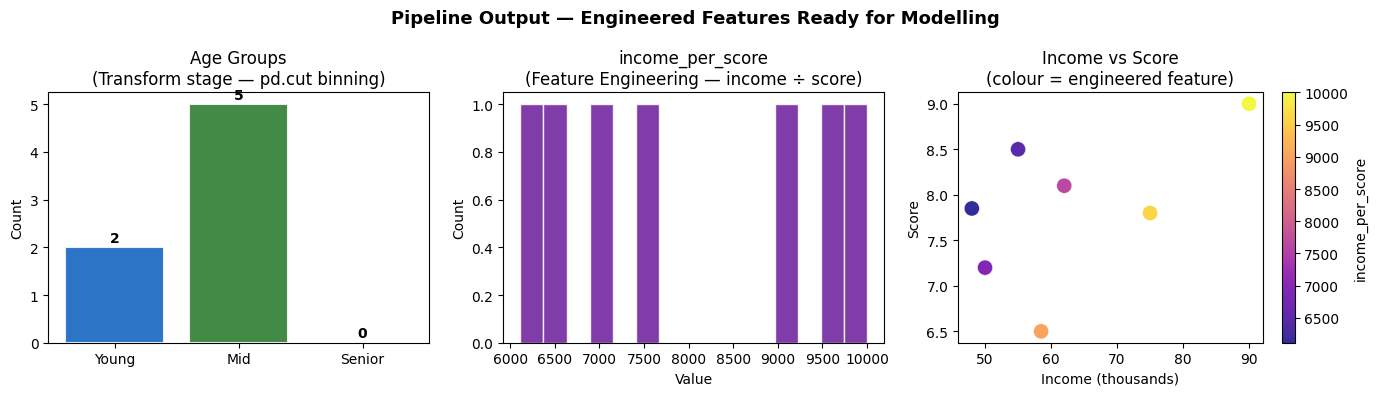

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Pipeline Output — Engineered Features Ready for Modelling',
             fontsize=13, fontweight='bold')

# Panel 1: Age group distribution (binning from Transform stage)
age_counts = result['age_group'].value_counts().reindex(['Young', 'Mid', 'Senior'])
colors_ag = ['#1565C0', '#2E7D32', '#E65100']
bars = axes[0].bar(age_counts.index, age_counts.values, color=colors_ag,
                   edgecolor='white', linewidth=1.5, alpha=0.9)
for bar, count in zip(bars, age_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 str(count), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Age Groups\n(Transform stage — pd.cut binning)')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')

# Panel 2: income_per_score histogram (engineered feature)
axes[1].hist(result['income_per_score'].dropna(), bins=15,
             color='#6A1B9A', edgecolor='white', alpha=0.85)
axes[1].set_title('income_per_score\n(Feature Engineering — income ÷ score)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')

# Panel 3: income_thousands vs score, coloured by income_per_score
sc = axes[2].scatter(
    result['income_thousands'], result['score'],
    c=result['income_per_score'], cmap='plasma',
    alpha=0.85, edgecolors='white', linewidth=0.4, s=120
)
plt.colorbar(sc, ax=axes[2], label='income_per_score')
axes[2].set_xlabel('Income (thousands)')
axes[2].set_ylabel('Score')
axes[2].set_title('Income vs Score\n(colour = engineered feature)')

plt.tight_layout()
plt.show()

## Key Takeaways

- A pipeline is **not just code** — it is an engineered process designed for reliability and scale.
- **Functional pipelines** are simple and predictable; ideal for straightforward workflows.
- **Class-based pipelines** maintain state (fit/transform); essential for ML workflows.
- You are not just writing analysis code — you are **designing systems**.